# Multi Layer Perceptron classification

Classification on two normal distributions.

Implement a simple MLP using the ReLU activation function.

In [1]:
import sys
sys.path.append('..')

import numpy as np
from matplotlib import pyplot as plt

from autodiff.functions import relu, sigmoid
from autodiff.variable import Variable
from nn.losses import bce_loss
from nn.modules import Linear, Module
from nn.optimizers import SGD


class ClassificationModel(Module):
    def __init__(self, in_features, out_features):
        self.linear1 = Linear(in_features, 4)
        self.linear2 = Linear(4, out_features)

    def forward(self, x):
        y = self.linear1(x)
        y = relu(y)
        y = self.linear2(y)
        return sigmoid(y)

Generate the data from to normal distributions. The model takes as input the $(x,y)$ coordinates of each point and predicts the probability of belonging to each class.

In [2]:
n1 = np.random.multivariate_normal([-0.5, 0.5], 0.1 * np.identity(2), [100])
n2 = np.random.multivariate_normal([0.5, -0.5], 0.1 * np.identity(2), [100])
normals = np.concatenate([n1, n2])
labels = [1.] * len(n1) + [0.] * len(n2)

data_x = [Variable(np.array([x])) for x in normals]
data_y = [Variable(np.array([[l]])) for l in labels]

Create the model and optimizer.

In [3]:
model = ClassificationModel(2, 1)
optimizer = SGD(model.parameters(), lr=1e-2)
epochs = 100

Train the model using the binary cross entropy loss.

Epoch 0: 0.6714671083364767
Epoch 1: 0.5915508211562045
Epoch 2: 0.516713208216824
Epoch 3: 0.4296243117575993
Epoch 4: 0.350568750151607
Epoch 5: 0.28856016421239483
Epoch 6: 0.24214579506167896
Epoch 7: 0.20755142772868254
Epoch 8: 0.18155571942808726
Epoch 9: 0.1610273476706644
Epoch 10: 0.14449165755362084
Epoch 11: 0.13080973580995736
Epoch 12: 0.11954520606255097
Epoch 13: 0.11000141079187202
Epoch 14: 0.10182587711735117
Epoch 15: 0.09475631435274938
Epoch 16: 0.08858150120978518
Epoch 17: 0.08314823375318323
Epoch 18: 0.07833042698671909
Epoch 19: 0.07408339179506852
Epoch 20: 0.0702662563717922
Epoch 21: 0.06681937103595129
Epoch 22: 0.06371501580794373
Epoch 23: 0.06088064416104148
Epoch 24: 0.05828804047859613
Epoch 25: 0.05590632993173673
Epoch 26: 0.053710322140131515
Epoch 27: 0.05167914063333548
Epoch 28: 0.04981238467196603
Epoch 29: 0.0480605300989334
Epoch 30: 0.04645087266660952
Epoch 31: 0.04492770758816114
Epoch 32: 0.04350257140989669
Epoch 33: 0.04216597279836532

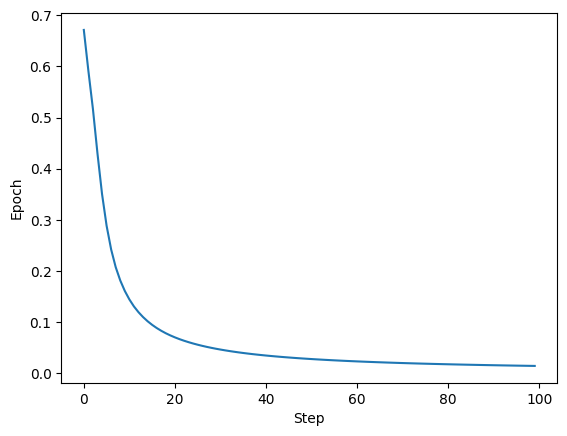

In [4]:
losses = []

for e in range(epochs):
    epoch_losses = []

    for (d, t) in zip(data_x, data_y):
        pred = model.forward(d)

        loss = bce_loss(pred, t)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        epoch_losses.append(loss.value.squeeze())

    epoch_loss = sum(epoch_losses) / len(data_x)
    print(f'Epoch {e}: {epoch_loss}')
    losses.append(epoch_loss)
pred = [model.forward(x).value for x in data_x]

plt.plot(np.arange(len(losses)), losses)
plt.xlabel('Step')
plt.ylabel('Epoch')
plt.show()

Test the model.

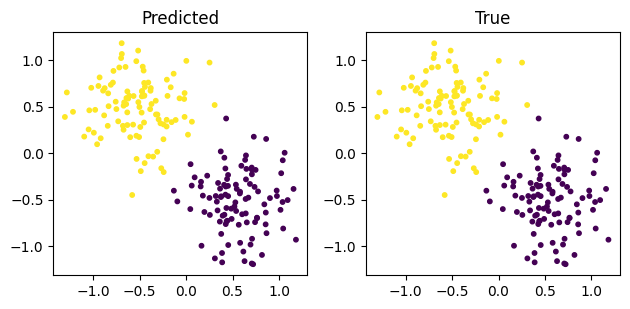

In [5]:
fig, (ax_pred, ax_true) = plt.subplots(1, 2)

x = np.concatenate(data_x)
pred = np.array(pred)

ax_pred.set_title('Predicted')
ax_pred.scatter(*x.T, c=np.astype(pred > 0.5, np.int64), s=10)
ax_pred.set_aspect('equal')

ax_true.set_title('True')
ax_true.scatter(*x.T, c=data_y, s=10)
ax_true.set_aspect('equal')

plt.tight_layout()
plt.show()

Plot the separation line between the classes.

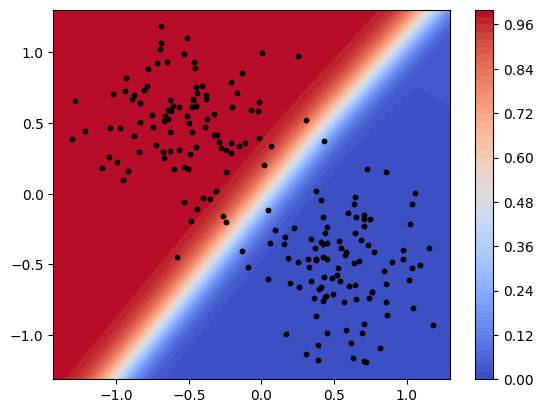

In [6]:
max_lim, min_lim = np.max(x, axis=0).flatten(), np.min(x, axis=0).flatten()
lims = list(zip(min_lim * 1.1, max_lim * 1.1))
grid_xx, grid_yy = np.meshgrid(np.linspace(*lims[0]), np.linspace(*lims[1]))
grid_x, grid_y = grid_xx.flatten(), grid_yy.flatten()
data = np.stack([grid_x, grid_y]).T
data = [Variable(d) for d in data]

pred = [model.forward(d) for d in data]

data = np.array(data)
proba = np.array(pred).reshape(grid_xx.shape)
contour = plt.contourf(grid_xx, grid_yy, proba, levels=50, vmin=0, vmax=1, cmap='coolwarm')
plt.colorbar(contour)

plt.scatter(*x.T, color='black', s=10)
plt.show()